In [ ]:
import pandas as pd
from pathlib import Path
import requests

MASTER = "http://data.gdeltproject.org/gdeltv2/masterfilelist.txt"

def download_gdeltv2_gkg_last_week(out_dir="gdeltv2_gkg_week", hourly=True):
    out = Path(out_dir)
    out.mkdir(parents=True, exist_ok=True)

    txt = requests.get(MASTER, timeout=120).text

    rows = []
    for line in txt.splitlines():
        parts = line.strip().split()
        if len(parts) >= 3:
            rows.append(parts[:3])
    mf = pd.DataFrame(rows, columns=["size", "md5", "url"])

    mf = mf[mf["url"].str.endswith(".gkg.csv.zip")].copy()

    mf["ts"] = mf["url"].str.extract(r"/(\d{14})\.gkg\.csv\.zip")[0]
    mf["dt"] = pd.to_datetime(mf["ts"], format="%Y%m%d%H%M%S", utc=True, errors="coerce")
    mf = mf.dropna(subset=["dt"])

    end = pd.Timestamp.utcnow().floor("D")
    start = end - pd.Timedelta(days=7)
    week = mf[(mf["dt"] >= start) & (mf["dt"] < end)].sort_values("dt")

    if hourly:
        week = week[week["dt"].dt.minute == 0]

    print("Will download:", len(week), "files")

    s = requests.Session()
    for url in week["url"]:
        fn = out / url.rsplit("/", 1)[-1]
        if fn.exists() and fn.stat().st_size > 0:
            continue
        r = s.get(url, timeout=180)
        r.raise_for_status()
        fn.write_bytes(r.content)

    print("Done ->", out)

download_gdeltv2_gkg_last_week(hourly=True)


Will download: 168 files
Done -> gdeltv2_gkg_week


In [ ]:
import zipfile, io
import pandas as pd
from pathlib import Path
import numpy as np

def read_gkg_zip(path: str) -> pd.DataFrame:
    with zipfile.ZipFile(path) as z:
        inner = z.namelist()[0]
        raw = z.read(inner)

    text = raw.decode("utf-8", errors="replace")

    df = pd.read_csv(
        io.StringIO(text),
        sep="\t",
        header=None,
        dtype=str,
        engine="python",
        on_bad_lines="skip"
    )
    return df

def parse_v2tone(v):
    if not isinstance(v, str) or v.strip() == "":
        return [np.nan]*7

    parts = v.split(",")
    parts += [None]*(7 - len(parts))

    out = []
    for p in parts[:7]:
        try:
            out.append(float(p))
        except:
            out.append(np.nan)
    return out

rows = []
for zp in Path("gdeltv2_gkg_week").glob("*.gkg.csv.zip"):
    rows.append(read_gkg_zip(str(zp)))
df = pd.concat(rows, ignore_index=True)


df.head()

df.shape


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,20251211000000-0,20251211000000,1,chinadaily.com.cn,http://www.chinadaily.com.cn/www.chinadaily.co...,NaN,NaN,EPU_CATS_REGULATION;WB_678_DIGITAL_GOVERNMENT;...,"EPU_CATS_REGULATION,9;WB_678_DIGITAL_GOVERNMEN...",1#China#CH#CH#35#105#CH,...,"wc:52,c12.1:4,c12.10:6,c12.12:2,c12.13:1,c12.1...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<PAGE_TITLE>China Daily Website - Connecting C...
1,20251211000000-1,20251211000000,1,cbc.bb,https://www.cbc.bb/main-stories/local-doctor-i...,NaN,NaN,TAX_ETHNICITY;TAX_ETHNICITY_BARBADIANS;TAX_FNC...,"HEALTH_PANDEMIC,620;WB_635_PUBLIC_HEALTH,620;W...",1#Barbados#BB#BB#13.166667#-59.533333#BB;1#Uni...,...,"wc:110,c12.1:10,c12.10:15,c12.12:8,c12.13:5,c1...",https://www.cbc.bb/wp-content/uploads/2025/12/...,NaN,NaN,https://youtube.com/c/cbcbarbados;https://yout...,NaN,"Barbados Association,221;Medical Practitioners...",NaN,NaN,<PAGE_AUTHORS>admin</PAGE_AUTHORS><PAGE_PRECIS...
2,20251211000000-2,20251211000000,1,iheart.com,https://941thebeat.iheart.com/content/2025-12-...,NaN,NaN,EDUCATION;SOC_POINTSOFINTEREST;SOC_POINTSOFINT...,"CRISISLEX_CRISISLEXREC,82;GENERAL_HEALTH,212;G...","2#Iowa, United States#US#USIA#42.0046#-93.214#...",...,"wc:174,c12.1:13,c12.10:21,c12.12:16,c12.13:4,c...",https://i.iheart.com/v3/re/assets.getty/6939d9...,NaN,https://pic.twitter.com/LQkARG8IHC;https://ins...,https://youtube.com/941thebeat;https://youtube...,NaN,"United States,47;Medical Center,243;Duchesne C...","3,dozen states,163;12,states,168;",NaN,<PAGE_LINKS>https://www.dailymail.co.uk/health...
3,20251211000000-3,20251211000000,1,iheart.com,https://600wmtradio.iheart.com/content/2025-12...,NaN,NaN,EPU_POLICY;EPU_POLICY_FEDERAL_RESERVE;EPU_CATS...,"TAX_FNCACT_OFFICIALS,1170;UNREST_BELLIGERENT,6...",1#United States#US#US#39.828175#-98.5795#US,...,"wc:217,c1.2:3,c1.3:2,c12.1:20,c12.10:29,c12.12...",https://i.iheart.com/v3/re/assets.getty/6939cb...,NaN,https://instagram.com/p/DSGBCfFElCs;https://pi...,https://youtube.com/oembed?format=json&omit_sc...,NaN,"Federal Reserve,20;Open Market Committee,348;P...","9,of the 12 Federal,234;12,Federal Open Market...",NaN,<PAGE_LINKS>https://abcnews.go.com/Business/di...
4,20251211000000-4,20251211000000,1,iheart.com,https://hits957.iheart.com/content/2025-12-10-...,KILL#48##0######;CRISISLEX_T03_DEAD#48##0######;,KILL#48##0#######151;CRISISLEX_T03_DEAD#48##0#...,MEDIA_MSM;KILL;CRISISLEX_T03_DEAD;TAX_FNCACT;T...,"TAX_FNCACT_MAN,1439;CRISISLEX_T11_UPDATESSYMPA...",NaN,...,"wc:244,c1.4:1,c12.1:31,c12.10:33,c12.12:5,c12....",https://i.iheart.com/v3/re/new_assets/6939e103...,NaN,https://instagram.com/p/DSGBCfFElCs;https://in...,https://youtube.com/embed/Kmw3hEUuBJU?feature=...,NaN,"Jeffrey Garcia,33;Sheen Estevez,89;Jimmy Neutr...",NaN,NaN,<PAGE_LINKS>https://www.iheart.com/artist/jimm...


In [21]:
df.shape

df.columns[:20]

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19], dtype='int64')

In [22]:
df.head(20)


,0,1,2,3,4,5,6,7,8,9,...,17,18,19,20,21,22,23,24,25,26
0,20251211000000-0,20251211000000,1,chinadaily.com.cn,http://www.chinadaily.com.cn/www.chinadaily.co...,NaN,NaN,EPU_CATS_REGULATION;WB_678_DIGITAL_GOVERNMENT;...,"EPU_CATS_REGULATION,9;WB_678_DIGITAL_GOVERNMEN...",1#China#CH#CH#35#105#CH,...,"wc:52,c12.1:4,c12.10:6,c12.12:2,c12.13:1,c12.1...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<PAGE_TITLE>China Daily Website - Connecting C...
1,20251211000000-1,20251211000000,1,cbc.bb,https://www.cbc.bb/main-stories/local-doctor-i...,NaN,NaN,TAX_ETHNICITY;TAX_ETHNICITY_BARBADIANS;TAX_FNC...,"HEALTH_PANDEMIC,620;WB_635_PUBLIC_HEALTH,620;W...",1#Barbados#BB#BB#13.166667#-59.533333#BB;1#Uni...,...,"wc:110,c12.1:10,c12.10:15,c12.12:8,c12.13:5,c1...",https://www.cbc.bb/wp-content/uploads/2025/12/...,NaN,NaN,https://youtube.com/c/cbcbarbados;https://yout...,NaN,"Barbados Association,221;Medical Practitioners...",NaN,NaN,<PAGE_AUTHORS>admin</PAGE_AUTHORS><PAGE_PRECIS...
2,20251211000000-2,20251211000000,1,iheart.com,https://941thebeat.iheart.com/content/2025-12-...,NaN,NaN,EDUCATION;SOC_POINTSOFINTEREST;SOC_POINTSOFINT...,"CRISISLEX_CRISISLEXREC,82;GENERAL_HEALTH,212;G...","2#Iowa, United States#US#USIA#42.0046#-93.214#...",...,"wc:174,c12.1:13,c12.10:21,c12.12:16,c12.13:4,c...",https://i.iheart.com/v3/re/assets.getty/6939d9...,NaN,https://pic.twitter.com/LQkARG8IHC;https://ins...,https://youtube.com/941thebeat;https://youtube...,NaN,"United States,47;Medical Center,243;Duchesne C...","3,dozen states,163;12,states,168;",NaN,<PAGE_LINKS>https://www.dailymail.co.uk/health...
3,20251211000000-3,20251211000000,1,iheart.com,https://600wmtradio.iheart.com/content/2025-12...,NaN,NaN,EPU_POLICY;EPU_POLICY_FEDERAL_RESERVE;EPU_CATS...,"TAX_FNCACT_OFFICIALS,1170;UNREST_BELLIGERENT,6...",1#United States#US#US#39.828175#-98.5795#US,...,"wc:217,c1.2:3,c1.3:2,c12.1:20,c12.10:29,c12.12...",https://i.iheart.com/v3/re/assets.getty/6939cb...,NaN,https://instagram.com/p/DSGBCfFElCs;https://pi...,https://youtube.com/oembed?format=json&omit_sc...,NaN,"Federal Reserve,20;Open Market Committee,348;P...","9,of the 12 Federal,234;12,Federal Open Market...",NaN,<PAGE_LINKS>https://abcnews.go.com/Business/di...
4,20251211000000-4,20251211000000,1,iheart.com,https://hits957.iheart.com/content/2025-12-10-...,KILL#48##0######;CRISISLEX_T03_DEAD#48##0######;,KILL#48##0#######151;CRISISLEX_T03_DEAD#48##0#...,MEDIA_MSM;KILL;CRISISLEX_T03_DEAD;TAX_FNCACT;T...,"TAX_FNCACT_MAN,1439;CRISISLEX_T11_UPDATESSYMPA...",NaN,...,"wc:244,c1.4:1,c12.1:31,c12.10:33,c12.12:5,c12....",https://i.iheart.com/v3/re/new_assets/6939e103...,NaN,https://instagram.com/p/DSGBCfFElCs;https://in...,https://youtube.com/embed/Kmw3hEUuBJU?feature=...,NaN,"Jeffrey Garcia,33;Sheen Estevez,89;Jimmy Neutr...",NaN,NaN,<PAGE_LINKS>https://www.iheart.com/artist/jimm...
5,20251211000000-5,20251211000000,1,prnewswire.com,https://www.prnewswire.com/news-releases/samsu...,NaN,NaN,WB_137_WATER;CRISISLEX_C07_SAFETY;WATER_SECURI...,"EPU_ECONOMY_HISTORIC,3504;ENV_GREEN,2090;WB_50...","4#Tokyo, Tokyo, Japan#JA#JA40#35.685#139.751#-...",...,"wc:456,c1.2:3,c1.3:7,c1.4:2,c12.1:21,c12.10:46...",NaN,NaN,NaN,NaN,NaN,"Water Security,44;South Korea,172;Samsung Biol...","5,plants,2250;",NaN,<PAGE_LINKS>https://samsungbiologics.com/</PAG...
6,20251211000000-6,20251211000000,1,theeagle.com,https://theeagle.com/news/local/article_c247ac...,NaN,NaN,EDUCATION;SOC_POINTSOFINTEREST;SOC_POINTSOFINT...,"TAX_WORLDMAMMALS_WOLF,64;EDUCATION,11;SOC_POIN...","3#Municipal Park, Texas, United States#US#USTX...",...,"wc:87,c12.1:4,c12.3:4,c12.5:4,c12.7:4,c12.9:4,...",https://bloximages.chicago2.vip.townnews.com/t...,NaN,NaN,NaN,NaN,"College Station Marathon,29;Wolf Pen Creek,75;...",NaN,NaN,<PAGE_AUTHORS>EAGLE STAFF REPORT;Stephen Whita...
7,20251211000000-7,20251211000000,1,iheart.com,https://1031wndh.iheart.com/content/2025-12-10...,NaN,NaN,AFFECT;WB_566_ENVIRONMENT_AND_NATURAL_RESOURCE...,"WB_566_ENVIRONMENT_AND_NATURAL_RESOURCES,102;W...",NaN,...,"wc:

In [29]:
import gdelt

gd2 = gdelt.gdelt(version=2)

gkg = gd2.Search(["2025 Dec 19"], table="gkg", coverage=True, output="pandas")
print(gkg.shape)
print(gkg.columns)
gkg.head()

(2746, 27)
Index(['GKGRECORDID', 'DATE', 'SourceCollectionIdentifier', 'SourceCommonName',
       'DocumentIdentifier', 'Counts', 'V2Counts', 'Themes', 'V2Themes',
       'Locations', 'V2Locations', 'Persons', 'V2Persons', 'Organizations',
       'V2Organizations', 'V2Tone', 'Dates', 'GCAM', 'SharingImage',
       'RelatedImages', 'SocialImageEmbeds', 'SocialVideoEmbeds', 'Quotations',
       'AllNames', 'Amounts', 'TranslationInfo', 'Extras'],
      dtype='object')


,GKGRECORDID,DATE,SourceCollectionIdentifier,SourceCommonName,DocumentIdentifier,Counts,V2Counts,Themes,V2Themes,Locations,...,GCAM,SharingImage,RelatedImages,SocialImageEmbeds,SocialVideoEmbeds,Quotations,AllNames,Amounts,TranslationInfo,Extras
0,20251219000000-0,20251219000000,1,comoxvalleyrecord.com,https://comoxvalleyrecord.com/2025/12/18/quesn...,NaN,NaN,UNGP_FORESTS_RIVERS_OCEANS;WB_135_TRANSPORT;WB...,"TAX_ECON_PRICE,1241;TAX_ECON_PRICE,3061;TAX_EC...","4#Vancouver, British Columbia, Canada#CA#CA02#...",...,"wc:1175,c12.1:65,c12.10:126,c12.12:24,c12.13:5...",https://comoxvalleyrecord.com/wp-content/uploa...,NaN,NaN,NaN,5876|54||big thing for our community with the ...,"North Vancouver,83;Prince George,101;Northern ...","5,months,1019;105,dollars ,1032;105,dollars ,1...",NaN,<PAGE_AUTHORS>none</PAGE_AUTHORS><PAGE_PRECISE...
1,20251219000000-1,20251219000000,1,deseret.com,https://www.deseret.com/u-s-world/2025/12/18/i...,"KILL#2#students#3#Brown University, Rhode Isla...","KILL#2#students#3#Brown University, Rhode Isla...",CRISISLEX_C07_SAFETY;EDUCATION;SOC_POINTSOFINT...,"TAX_WORLDLANGUAGES_MASSACHUSETTS,176;TAX_WORLD...","2#Rhode Island, United States#US#USRI#41.6772#...",...,"wc:268,c12.1:11,c12.10:15,c12.12:9,c12.13:1,c1...",https://www.deseret.com/resizer/v2/NACCXETSJBH...,NaN,NaN,https://youtube.com/channel/UCP7SfUaCqZNYBwM6o...,NaN,"Brown University,77;New York,528;Rhode Island,...","45,miles,593;2,students were killed,622;50,dol...",NaN,<PAGE_LINKS>https://www.cbsnews.com/amp/news/p...
2,20251219000000-2,20251219000000,1,ktvz.com,https://ktvz.com/politics/cnn-us-politics/2025...,NaN,NaN,LEADER;TAX_FNCACT;TAX_FNCACT_PRESIDENT;TAX_FNC...,"GENERAL_HEALTH,225;GENERAL_HEALTH,344;GENERAL_...","3#White House, District Of Columbia, United St...",...,"wc:1369,c1.2:12,c12.1:84,c12.10:137,c12.12:37,...",https://ktvz.b-cdn.net/2025/12/cnn-L19jb21wb25...,NaN,NaN,NaN,1922|74||update the statutory definition of fi...,"Kit Maher,13;Steve Contorno,33;Sarah Owermohle...","1,drug,759;3,drug,931;4,milligrams of THC per,...",NaN,<PAGE_LINKS>https://www.cnn.com/2023/10/02/inv...
3,20251219000000-3,20251219000000,1,miragenews.com,https://www.miragenews.com/construction-comple...,NaN,NaN,CRISISLEX_C03_WELLBEING_HEALTH;GENERAL_GOVERNM...,"ALLIANCE,1285;LEADER,1642;TAX_FNCACT_MAYOR,164...",NaN,...,"wc:401,c1.1:1,c12.1:27,c12.10:41,c12.12:11,c12...",https://www.mornpen.vic.gov.au/files/assets/pu...,NaN,NaN,NaN,NaN,"Rye Township Plan,134;Rye Foreshore Park,348;N...","1,of the Rye Township,88;2,plaza areas on eith...",NaN,<PAGE_LINKS>https://www.miragenews.com/constru...
4,20251219000000-4,20251219000000,1,accountingtoday.com,https://www.accountingtoday.com/news/sorren-ad...,NaN,NaN,UNGP_FORESTS_RIVERS_OCEANS;GENERAL_HEALTH;MEDI...,"LEADER,1424;TAX_FNCACT_PRESIDENT,1424;USPEC_PO...","2#Idaho, United States#US#USID#44.2394#-114.51...",...,"wc:241,c12.1:21,c12.10:18,c12.12:1,c12.13:7,c1...",https://source-media-brightspot.s3.us-east-1.a...,NaN,NaN,NaN,NaN,"Casey Neilon,69;Carson City,269;Casey Neilon,4...","33,professional staff,275;6,partners,320;100,p...",NaN,<PAGE_LINKS>https://www.accountingtoday.com/li...


In [30]:
def parse_tone_bundle(v, k=7):
    """Parse comma-separated tone bundle into floats; pad/NaN on errors."""
    if not isinstance(v, str) or v.strip() == "":
        return [np.nan]*k
    parts = v.split(",")
    parts += [None]*(k - len(parts))
    out = []
    for p in parts[:k]:
        try:
            out.append(float(p))
        except:
            out.append(np.nan)
    return out

tone_col = "V2Tone" if "V2Tone" in gkg.columns else ("Tone" if "Tone" in gkg.columns else None)
if tone_col is None:
    raise KeyError("No V2Tone or Tone column found. Print gkg.columns to inspect.")

tone_cols = ["tone","pos","neg","polarity","activity_ref","self_group_ref","wordcount"]
gkg[tone_cols] = gkg[tone_col].apply(lambda x: pd.Series(parse_tone_bundle(x, k=len(tone_cols))))


In [31]:
def count_list(s, sep=";"):
    if not isinstance(s, str) or s.strip()=="":
        return 0
    return len([x for x in s.split(sep) if x.strip()])

for col, newcol in [
    ("Themes", "n_themes"),
    ("Locations", "n_locations"),
    ("Persons", "n_persons"),
    ("Organizations", "n_orgs"),
]:
    if col in gkg.columns:
        gkg[newcol] = gkg[col].apply(count_list)


In [ ]:
gkg = gkg.replace({"": np.nan})

if "DATE" in gkg.columns:
    gkg["date_dt"] = pd.to_datetime(gkg["DATE"], format="%Y%m%d%H%M%S", errors="coerce")
    gkg = gkg.dropna(subset=["date_dt"])

for rid in ["GKGRECORDID", "GKGRecordID"]:
    if rid in gkg.columns:
        gkg = gkg.drop_duplicates(subset=[rid])
        break
print("Final GKG shape:", gkg.shape)

Final GKG shape: (2746, 39)


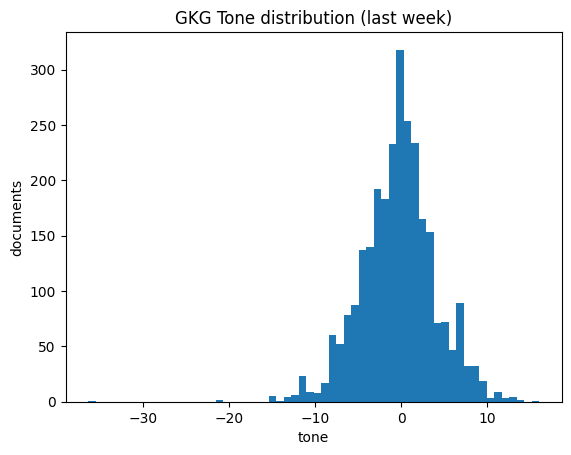

In [33]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(gkg["tone"].dropna(), bins=60)
plt.title("GKG Tone distribution (last week)")
plt.xlabel("tone")
plt.ylabel("documents")
plt.show()


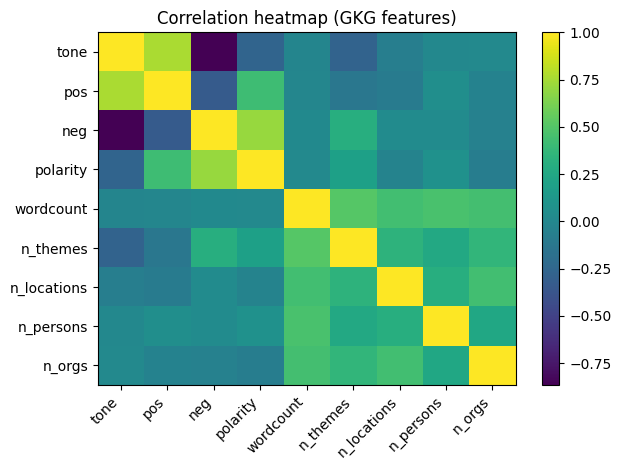

In [34]:
num_cols = [c for c in ["tone","pos","neg","polarity","wordcount","n_themes","n_locations","n_persons","n_orgs"] if c in gkg.columns]
corr = gkg[num_cols].corr(numeric_only=True)

plt.figure()
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Correlation heatmap (GKG features)")
plt.colorbar()
plt.tight_layout()
plt.show()


In [36]:
import gdelt

gd2 = gdelt.gdelt(version=2)

gkg = gd2.Search(["2025 Dec 19"], table="gkg", coverage=True, output="pandas")
print(gkg.shape)
print(gkg.columns)
gkg.head()

(4175, 27)
Index(['GKGRECORDID', 'DATE', 'SourceCollectionIdentifier', 'SourceCommonName',
       'DocumentIdentifier', 'Counts', 'V2Counts', 'Themes', 'V2Themes',
       'Locations', 'V2Locations', 'Persons', 'V2Persons', 'Organizations',
       'V2Organizations', 'V2Tone', 'Dates', 'GCAM', 'SharingImage',
       'RelatedImages', 'SocialImageEmbeds', 'SocialVideoEmbeds', 'Quotations',
       'AllNames', 'Amounts', 'TranslationInfo', 'Extras'],
      dtype='object')


,GKGRECORDID,DATE,SourceCollectionIdentifier,SourceCommonName,DocumentIdentifier,Counts,V2Counts,Themes,V2Themes,Locations,...,GCAM,SharingImage,RelatedImages,SocialImageEmbeds,SocialVideoEmbeds,Quotations,AllNames,Amounts,TranslationInfo,Extras
0,20251219000000-0,20251219000000,1,comoxvalleyrecord.com,https://comoxvalleyrecord.com/2025/12/18/quesn...,NaN,NaN,UNGP_FORESTS_RIVERS_OCEANS;WB_135_TRANSPORT;WB...,"TAX_ECON_PRICE,1241;TAX_ECON_PRICE,3061;TAX_EC...","4#Vancouver, British Columbia, Canada#CA#CA02#...",...,"wc:1175,c12.1:65,c12.10:126,c12.12:24,c12.13:5...",https://comoxvalleyrecord.com/wp-content/uploa...,NaN,NaN,NaN,5876|54||big thing for our community with the ...,"North Vancouver,83;Prince George,101;Northern ...","5,months,1019;105,dollars ,1032;105,dollars ,1...",NaN,<PAGE_AUTHORS>none</PAGE_AUTHORS><PAGE_PRECISE...
1,20251219000000-1,20251219000000,1,deseret.com,https://www.deseret.com/u-s-world/2025/12/18/i...,"KILL#2#students#3#Brown University, Rhode Isla...","KILL#2#students#3#Brown University, Rhode Isla...",CRISISLEX_C07_SAFETY;EDUCATION;SOC_POINTSOFINT...,"TAX_WORLDLANGUAGES_MASSACHUSETTS,176;TAX_WORLD...","2#Rhode Island, United States#US#USRI#41.6772#...",...,"wc:268,c12.1:11,c12.10:15,c12.12:9,c12.13:1,c1...",https://www.deseret.com/resizer/v2/NACCXETSJBH...,NaN,NaN,https://youtube.com/channel/UCP7SfUaCqZNYBwM6o...,NaN,"Brown University,77;New York,528;Rhode Island,...","45,miles,593;2,students were killed,622;50,dol...",NaN,<PAGE_LINKS>https://www.cbsnews.com/amp/news/p...
2,20251219000000-2,20251219000000,1,ktvz.com,https://ktvz.com/politics/cnn-us-politics/2025...,NaN,NaN,LEADER;TAX_FNCACT;TAX_FNCACT_PRESIDENT;TAX_FNC...,"GENERAL_HEALTH,225;GENERAL_HEALTH,344;GENERAL_...","3#White House, District Of Columbia, United St...",...,"wc:1369,c1.2:12,c12.1:84,c12.10:137,c12.12:37,...",https://ktvz.b-cdn.net/2025/12/cnn-L19jb21wb25...,NaN,NaN,NaN,1922|74||update the statutory definition of fi...,"Kit Maher,13;Steve Contorno,33;Sarah Owermohle...","1,drug,759;3,drug,931;4,milligrams of THC per,...",NaN,<PAGE_LINKS>https://www.cnn.com/2023/10/02/inv...
3,20251219000000-3,20251219000000,1,miragenews.com,https://www.miragenews.com/construction-comple...,NaN,NaN,CRISISLEX_C03_WELLBEING_HEALTH;GENERAL_GOVERNM...,"ALLIANCE,1285;LEADER,1642;TAX_FNCACT_MAYOR,164...",NaN,...,"wc:401,c1.1:1,c12.1:27,c12.10:41,c12.12:11,c12...",https://www.mornpen.vic.gov.au/files/assets/pu...,NaN,NaN,NaN,NaN,"Rye Township Plan,134;Rye Foreshore Park,348;N...","1,of the Rye Township,88;2,plaza areas on eith...",NaN,<PAGE_LINKS>https://www.miragenews.com/constru...
4,20251219000000-4,20251219000000,1,accountingtoday.com,https://www.accountingtoday.com/news/sorren-ad...,NaN,NaN,UNGP_FORESTS_RIVERS_OCEANS;GENERAL_HEALTH;MEDI...,"LEADER,1424;TAX_FNCACT_PRESIDENT,1424;USPEC_PO...","2#Idaho, United States#US#USID#44.2394#-114.51...",...,"wc:241,c12.1:21,c12.10:18,c12.12:1,c12.13:7,c1...",https://source-media-brightspot.s3.us-east-1.a...,NaN,NaN,NaN,NaN,"Casey Neilon,69;Carson City,269;Casey Neilon,4...","33,professional staff,275;6,partners,320;100,p...",NaN,<PAGE_LINKS>https://www.accountingtoday.com/li...


In [37]:
def parse_tone_bundle(v, k=7):
    """Parse comma-separated tone bundle into floats; pad/NaN on errors."""
    if not isinstance(v, str) or v.strip() == "":
        return [np.nan]*k
    parts = v.split(",")
    parts += [None]*(k - len(parts))
    out = []
    for p in parts[:k]:
        try:
            out.append(float(p))
        except:
            out.append(np.nan)
    return out

tone_col = "V2Tone" if "V2Tone" in gkg.columns else ("Tone" if "Tone" in gkg.columns else None)
if tone_col is None:
    raise KeyError("No V2Tone or Tone column found. Print gkg.columns to inspect.")

tone_cols = ["tone","pos","neg","polarity","activity_ref","self_group_ref","wordcount"]
gkg[tone_cols] = gkg[tone_col].apply(lambda x: pd.Series(parse_tone_bundle(x, k=len(tone_cols))))


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def ensure_datetime(df):
    if "date_dt" in df.columns:
        return df
    if "DATE" in df.columns:
        df = df.copy()
        df["date_dt"] = pd.to_datetime(df["DATE"], format="%Y%m%d%H%M%S", errors="coerce")
        df = df.dropna(subset=["date_dt"])
        return df
    raise KeyError("Need DATE or date_dt to do time-based EDA.")

def count_list(s, sep=";"):
    if not isinstance(s, str) or s.strip() == "":
        return 0
    return len([x for x in s.split(sep) if x.strip()])

def explode_list_col(df, col, sep=";"):
    """Explode a semicolon-separated list column into long form."""
    if col not in df.columns:
        raise KeyError(f"Missing column: {col}")
    out = df[[c for c in df.columns if c != col]].copy()
    tmp = df[col].fillna("").astype(str).str.split(sep)
    out[col] = tmp
    out = out.explode(col)
    out[col] = out[col].astype(str).str.strip()
    out = out[out[col] != ""]
    return out

gkg = ensure_datetime(gkg)
gkg["day"] = gkg["date_dt"].dt.floor("D")
gkg["hour"] = gkg["date_dt"].dt.hour
gkg["dow"] = gkg["date_dt"].dt.day_name()


In [39]:
miss = (gkg.isna().mean().sort_values(ascending=False) * 100).round(2)
print(miss.head(30))


TranslationInfo               100.00
SocialImageEmbeds              89.10
RelatedImages                  88.24
V2Counts                       85.70
Counts                         85.70
Quotations                     79.04
Dates                          68.74
SocialVideoEmbeds              44.67
V2Organizations                25.60
Organizations                  23.52
Amounts                        23.31
V2Locations                    23.14
Locations                      23.11
V2Persons                      20.12
Persons                        18.30
SharingImage                   12.86
V2Themes                        9.03
Themes                          9.03
AllNames                        4.46
GKGRECORDID                     0.00
SourceCollectionIdentifier      0.00
DATE                            0.00
DocumentIdentifier              0.00
SourceCommonName                0.00
V2Tone                          0.00
GCAM                            0.00
Extras                          0.00
t

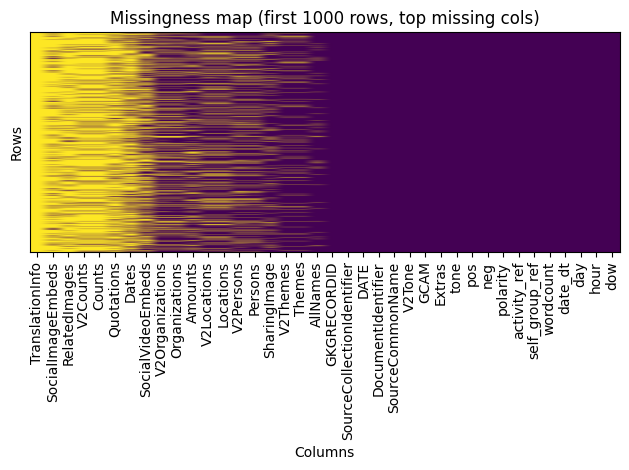

In [ ]:
cols = miss.index[:40].tolist()
mat = gkg[cols].isna().astype(int).head(1000).to_numpy()

plt.figure()
plt.imshow(mat, aspect="auto")
plt.title("Missingness map (first 1000 rows, top missing cols)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.xticks(range(len(cols)), cols, rotation=90)
plt.yticks([])
plt.tight_layout()
plt.show()


In [41]:
for key in ["GKGRECORDID", "GKGRecordID", "DocumentIdentifier"]:
    if key in gkg.columns:
        dup_rate = gkg.duplicated(subset=[key]).mean()
        print(f"Duplicate rate by {key}: {dup_rate:.3%}")


Duplicate rate by GKGRECORDID: 0.000%
Duplicate rate by DocumentIdentifier: 0.000%


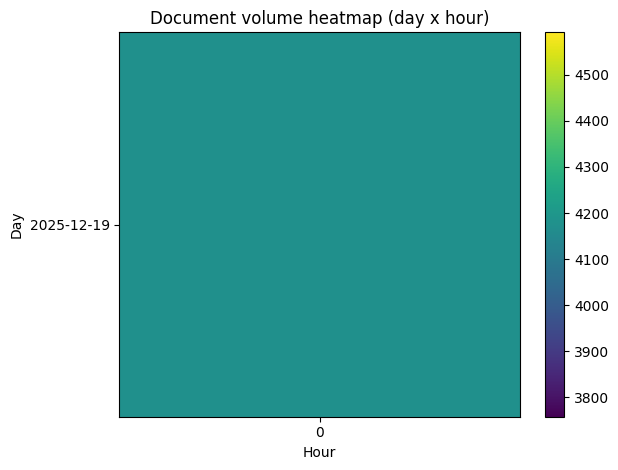

In [42]:
vol = (gkg.groupby(["day","hour"]).size().unstack(fill_value=0)).sort_index()

plt.figure()
plt.imshow(vol.to_numpy(), aspect="auto")
plt.title("Document volume heatmap (day x hour)")
plt.xlabel("Hour")
plt.ylabel("Day")
plt.xticks(range(vol.shape[1]), vol.columns)
plt.yticks(range(vol.shape[0]), [d.strftime("%Y-%m-%d") for d in vol.index])
plt.colorbar()
plt.tight_layout()
plt.show()


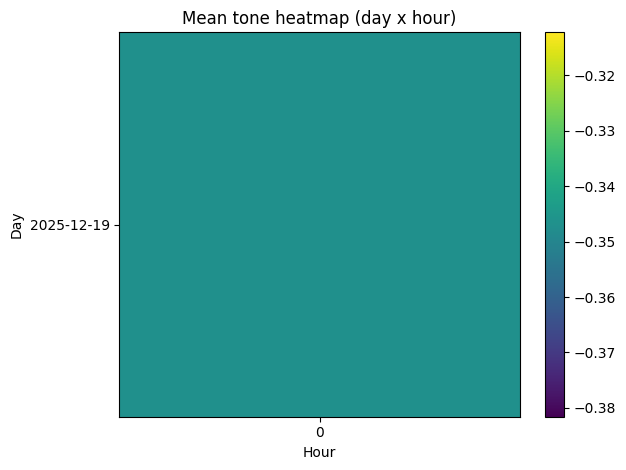

In [43]:
if "tone" in gkg.columns:
    mt = (gkg.groupby(["day","hour"])["tone"].mean().unstack())
    plt.figure()
    plt.imshow(mt.to_numpy(), aspect="auto")
    plt.title("Mean tone heatmap (day x hour)")
    plt.xlabel("Hour")
    plt.ylabel("Day")
    plt.xticks(range(mt.shape[1]), mt.columns)
    plt.yticks(range(mt.shape[0]), [d.strftime("%Y-%m-%d") for d in mt.index])
    plt.colorbar()
    plt.tight_layout()
    plt.show()


tone p01/p99: -11.8721461187215 9.39303576682218


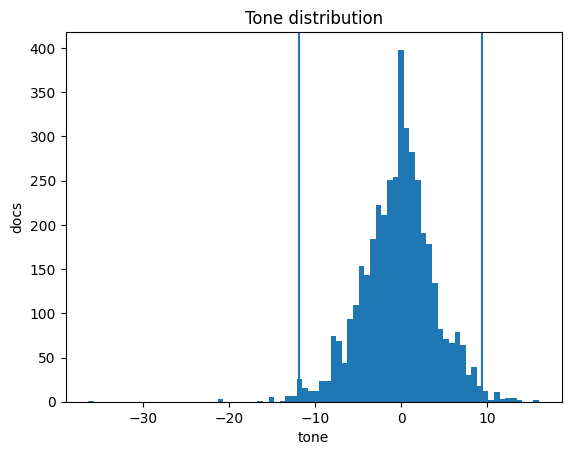

In [44]:
if "tone" in gkg.columns:
    x = gkg["tone"].dropna().astype(float)
    p1, p99 = x.quantile([0.01, 0.99])
    print("tone p01/p99:", float(p1), float(p99))

    plt.figure()
    plt.hist(x, bins=80)
    plt.title("Tone distribution")
    plt.xlabel("tone")
    plt.ylabel("docs")
    plt.axvline(p1)
    plt.axvline(p99)
    plt.show()


C:\Users\hucu\AppData\Local\Temp\ipykernel_36216\2337570083.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=[pd.Timestamp(d).strftime("%m-%d") for d in days], showfliers=False)


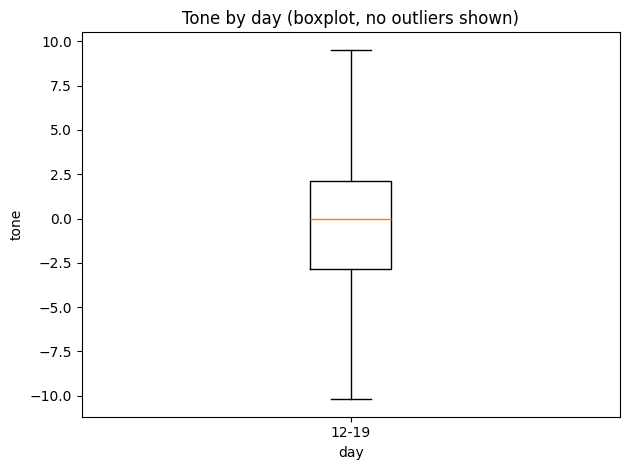

In [45]:
if "tone" in gkg.columns:
    daily = gkg.dropna(subset=["tone"]).copy()
    days = sorted(daily["day"].unique())
    data = [daily.loc[daily["day"]==d, "tone"].astype(float).values for d in days]

    plt.figure()
    plt.boxplot(data, labels=[pd.Timestamp(d).strftime("%m-%d") for d in days], showfliers=False)
    plt.title("Tone by day (boxplot, no outliers shown)")
    plt.xlabel("day")
    plt.ylabel("tone")
    plt.tight_layout()
    plt.show()


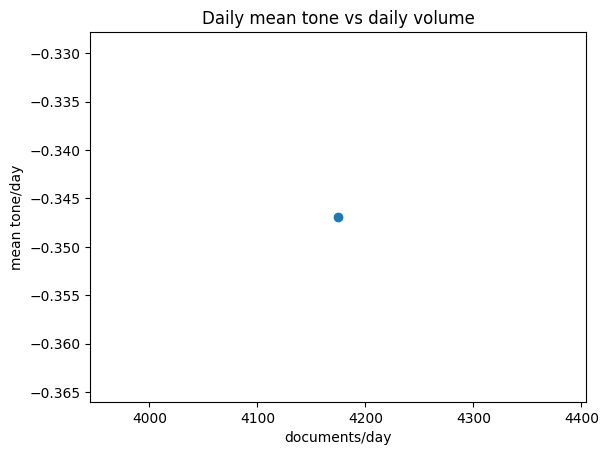

In [46]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")
             .agg(documents=("day","size"), mean_tone=("tone","mean"))
             .reset_index())
    x = daily["documents"].to_numpy()
    y = daily["mean_tone"].to_numpy()

    plt.figure()
    plt.scatter(x, y)
    if len(x) >= 2:
        m, b = np.polyfit(x, y, 1)
        xx = np.linspace(x.min(), x.max(), 100)
        plt.plot(xx, m*xx + b)
    plt.title("Daily mean tone vs daily volume")
    plt.xlabel("documents/day")
    plt.ylabel("mean tone/day")
    plt.show()


In [47]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")
             .agg(documents=("day","size"), mean_tone=("tone","mean"))
             .sort_index())
    max_lag = 3
    for lag in range(-max_lag, max_lag+1):
        corr = daily["documents"].corr(daily["mean_tone"].shift(lag))
        print(f"corr(documents, mean_tone shifted {lag:+d}d): {corr:.3f}")


corr(documents, mean_tone shifted -3d): nan
corr(documents, mean_tone shifted -2d): nan
corr(documents, mean_tone shifted -1d): nan
corr(documents, mean_tone shifted +0d): nan
corr(documents, mean_tone shifted +1d): nan
corr(documents, mean_tone shifted +2d): nan
corr(documents, mean_tone shifted +3d): nan


c:\Users\hucu\Desktop\Big-Data-Analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3057: RuntimeWarning: Degrees of freedom <= 0 for slice
  c = cov(x, y, rowvar, dtype=dtype)
c:\Users\hucu\Desktop\Big-Data-Analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: divide by zero encountered in divide
  c *= np.true_divide(1, fact)
c:\Users\hucu\Desktop\Big-Data-Analytics\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:2914: RuntimeWarning: invalid value encountered in multiply
  c *= np.true_divide(1, fact)


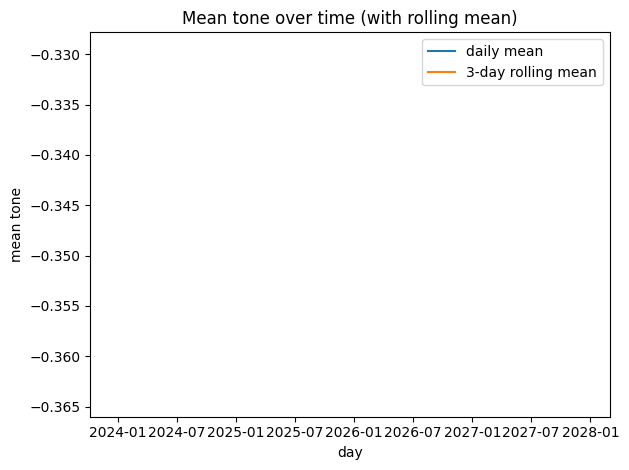

In [48]:
if "tone" in gkg.columns:
    daily = (gkg.groupby("day")["tone"].mean().sort_index())
    roll = daily.rolling(3, min_periods=1)
    plt.figure()
    plt.plot(daily.index, daily.values, label="daily mean")
    plt.plot(roll.mean().index, roll.mean().values, label="3-day rolling mean")
    plt.title("Mean tone over time (with rolling mean)")
    plt.xlabel("day")
    plt.ylabel("mean tone")
    plt.legend()
    plt.tight_layout()
    plt.show()


                     documents  mean_tone
SourceCommonName                         
iheart.com                 252  -1.212864
biztoc.com                  56  -0.993632
yahoo.com                   44  -0.680788
openpr.com                  37   3.617434
themarketsdaily.com         32   1.979660
indiatimes.com              28  -0.384970
miragenews.com              27  -0.096082
dailybulletin.com           24   0.000887
dailypolitical.com          23   1.959541
clevelandstar.com           23   0.643288
foxbaltimore.com            22  -1.356452
presstelegram.com           21  -0.471800
mynorthwest.com             21  -2.372750
newswiretoday.com           20   3.616799
bignewsnetwork.com          19  -1.016182
forbes.com                  19  -0.194907
wdio.com                    19  -0.622960
el-balad.com                19   0.578919
hawaiitelegraph.com         19   0.517596
island.lk                   19  -0.963898


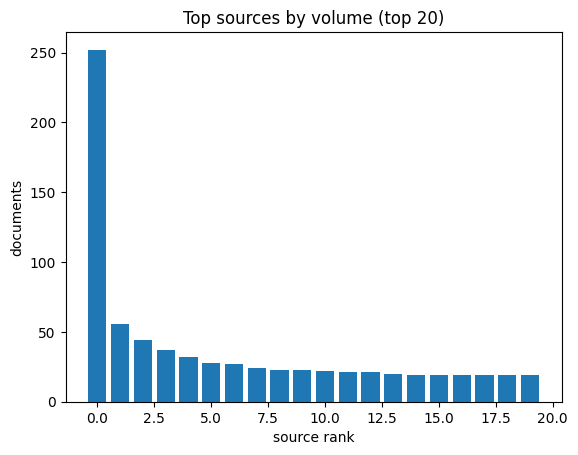

In [49]:
src_col = None
for c in ["SourceCommonName", "sourceCommonName", "Source"]:
    if c in gkg.columns:
        src_col = c
        break

if src_col and "tone" in gkg.columns:
    top = (gkg.groupby(src_col)
           .agg(documents=("tone","size"), mean_tone=("tone","mean"))
           .sort_values("documents", ascending=False)
           .head(20))
    print(top)

    plt.figure()
    plt.bar(range(len(top)), top["documents"].to_numpy())
    plt.title("Top sources by volume (top 20)")
    plt.xlabel("source rank")
    plt.ylabel("documents")
    plt.show()


                                         mentions  mean_tone
Themes                                                      
TAX_FNCACT                                   3317  -0.536194
EPU_POLICY                                   1673  -1.610342
CRISISLEX_CRISISLEXREC                       1429  -2.593289
TAX_ETHNICITY                                1281  -0.644568
USPEC_POLITICS_GENERAL1                      1180  -0.802528
LEADER                                       1174  -0.799807
WB_696_PUBLIC_SECTOR_MANAGEMENT              1164  -1.970691
SOC_POINTSOFINTEREST                         1157  -1.612544
UNGP_FORESTS_RIVERS_OCEANS                   1140  -0.392180
CRISISLEX_C07_SAFETY                         1037  -2.989100
EPU_ECONOMY_HISTORIC                         1018   0.273912
USPEC_POLICY1                                 981  -0.623269
EDUCATION                                     902  -0.433906
MANMADE_DISASTER_IMPLIED                      901  -2.369198
WB_621_HEALTH_NUTRITION_

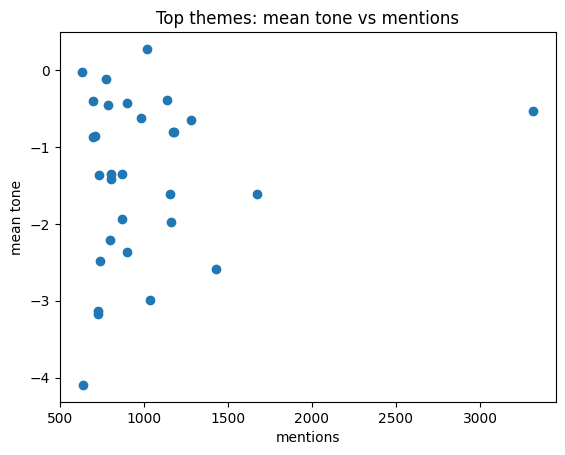

In [ ]:
theme_col = "Themes" if "Themes" in gkg.columns else ("V2Themes" if "V2Themes" in gkg.columns else None)

if theme_col and "tone" in gkg.columns:
    long = explode_list_col(gkg[[theme_col, "tone"]].dropna(subset=["tone"]), theme_col)
    theme_stats = (long.groupby(theme_col)
                   .agg(mentions=(theme_col,"size"), mean_tone=("tone","mean"))
                   .sort_values("mentions", ascending=False)
                   .head(30))
    print(theme_stats.head(20))

    plt.figure()
    plt.scatter(theme_stats["mentions"], theme_stats["mean_tone"])
    plt.title("Top themes: mean tone vs mentions")
    plt.xlabel("mentions")
    plt.ylabel("mean tone")
    plt.show()


C:\Users\hucu\AppData\Local\Temp\ipykernel_36216\518676286.py:33: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


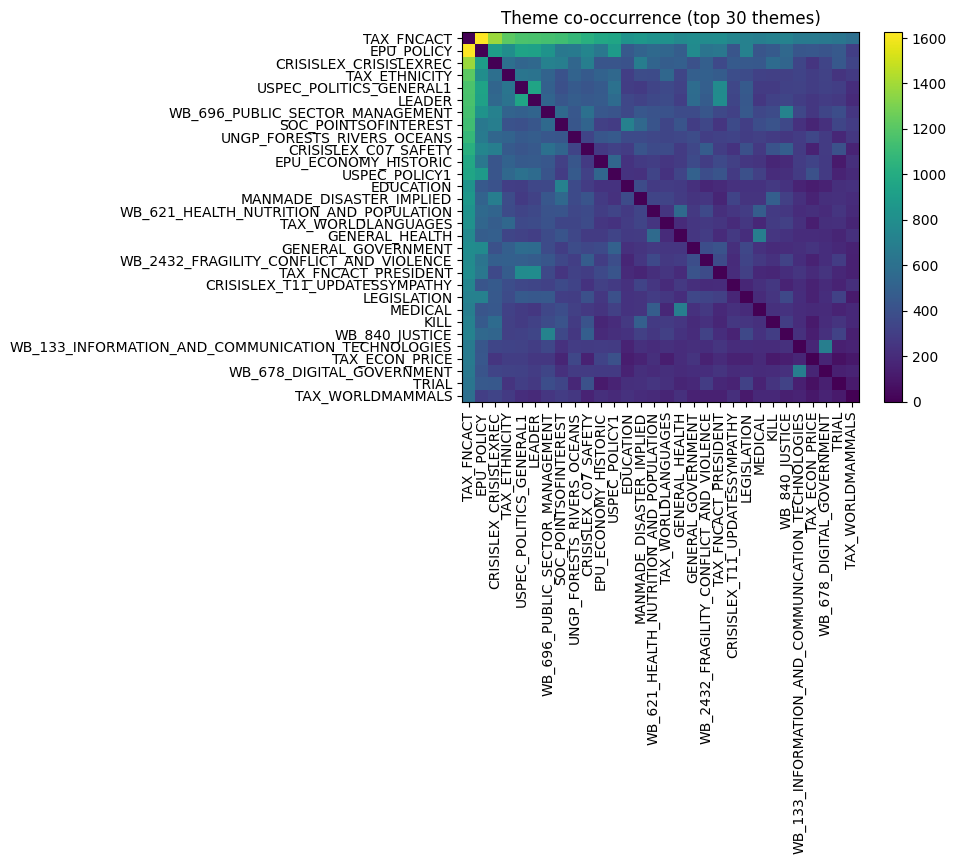

In [ ]:
from collections import Counter
import itertools

if theme_col:
    topN = 30
    long = explode_list_col(gkg[[theme_col]].copy(), theme_col)
    top_themes = long[theme_col].value_counts().head(topN).index.tolist()
    top_set = set(top_themes)

    pair_counts = Counter()
    for s in gkg[theme_col].fillna("").astype(str):
        items = [t.strip() for t in s.split(";") if t.strip() in top_set]
        items = sorted(set(items))
        for a, b in itertools.combinations(items, 2):
            pair_counts[(a,b)] += 1

    idx = {t:i for i,t in enumerate(top_themes)}
    M = np.zeros((topN, topN), dtype=int)
    for (a,b), v in pair_counts.items():
        i, j = idx[a], idx[b]
        M[i,j] = v
        M[j,i] = v

    plt.figure()
    plt.imshow(M, aspect="auto")
    plt.title("Theme co-occurrence (top 30 themes)")
    plt.xticks(range(topN), top_themes, rotation=90)
    plt.yticks(range(topN), top_themes)
    plt.colorbar()
    plt.tight_layout()
    plt.show()


Anomalous days (|z|>=2):
Series([], dtype: float64)


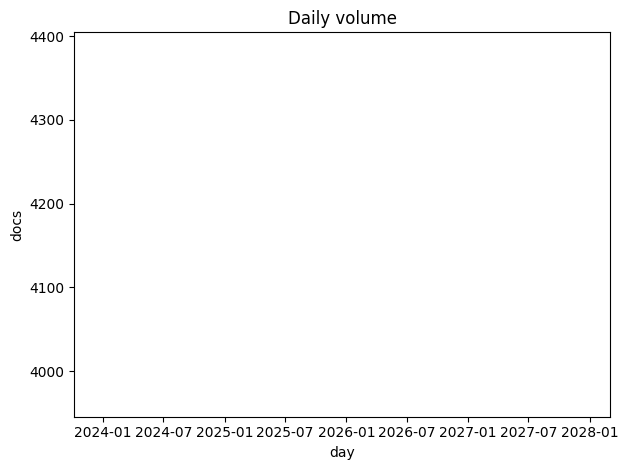

In [52]:
daily_vol = gkg.groupby("day").size().sort_index()
z = (daily_vol - daily_vol.mean()) / (daily_vol.std(ddof=0) + 1e-9)

print("Anomalous days (|z|>=2):")
print(z[abs(z) >= 2].sort_values(ascending=False))

plt.figure()
plt.plot(daily_vol.index, daily_vol.values)
plt.title("Daily volume")
plt.xlabel("day")
plt.ylabel("docs")
plt.tight_layout()
plt.show()


In [53]:
if "tone" in gkg.columns:
    daily_tone = gkg.groupby("day")["tone"].mean().sort_index()
    zt = (daily_tone - daily_tone.mean()) / (daily_tone.std(ddof=0) + 1e-9)
    print("Tone shock days (|z|>=2):")
    print(zt[abs(zt) >= 2].sort_values(ascending=False))


Tone shock days (|z|>=2):
Series([], Name: tone, dtype: float64)


# Top N entities by mention volume

In [ ]:
from collections import Counter

def extract_names(series, sep=";"):
    c = Counter()
    for s in series.dropna().astype(str):
        for item in s.split(sep):
            item = item.strip()
            if not item:
                continue
            name = item.split(",")[0].strip()
            if name:
                c[name] += 1
    return c

entity_source_col = None
for col in ["Persons", "Organizations", "AllNames", "V2Persons", "V2Organizations"]:
    if col in gkg.columns:
        entity_source_col = col
        break

counts = extract_names(gkg[entity_source_col])
top_entities = [e for e,_ in counts.most_common(50)]
top_entities[:50], len(top_entities)


(['donald trump',
  'joe biden',
  'greg biffle',
  'los angeles',
  'pete davidson',
  'elsie hewitt',
  'dennis dutton',
  'craig wadsworth',
  'nuno f g loureiro',
  'megan fox',
  'anthony albanese',
  'las vegas',
  'brett smiley',
  'charlie kirk',
  'mehmet oz',
  'nuno loureiro',
  'jason deford',
  'seattle seahawks',
  'karoline leavitt',
  'bill lee',
  'david gonski',
  'jeffrey epstein',
  'barack obama',
  'paul l hoback jr',
  'daron hall',
  'richard hudson',
  'nicole lunders',
  'brian thompson',
  'robert f kennedy jr',
  'garth brooks',
  'mickey guyton',
  'trisha yearwood',
  'heartcountry christmas',
  'chris young',
  'luke bryan',
  'hannah ellis',
  'gabby barrett',
  'brad paisley',
  'hunter hayes',
  'nick wayne',
  'leann rimes',
  'hakeem jeffries',
  'wiz khalifa',
  'garrett mitchell',
  'peter neronha',
  'ted budd',
  'puka nacua',
  'zohran mamdani',
  'rob reiner',
  'josh stein'],
 50)

In [ ]:
import requests
import time

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "GDELT-WikiEdits-Correlation/0.1 (student project; contact: 01171199@pw.edu.pl)"
})

def wiki_search_title(query, wiki="en.wikipedia.org", sleep_s=0.2):
    url = f"https://{wiki}/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "list": "search",
        "srsearch": query,
        "srlimit": 1
    }
    r = SESSION.get(url, params=params, timeout=30)
    if r.status_code == 429:
        time.sleep(2)
        r = SESSION.get(url, params=params, timeout=30)

    r.raise_for_status()
    hits = r.json().get("query", {}).get("search", [])
    time.sleep(sleep_s)
    return hits[0]["title"] if hits else None


entity_to_title = {}
for e in top_entities:
    title = wiki_search_title(e)
    if title:
        entity_to_title[e] = title

list(entity_to_title.items())[:10], len(entity_to_title)


([('donald trump', 'Donald Trump'),
  ('joe biden', 'Joe Biden'),
  ('greg biffle', 'Greg Biffle'),
  ('los angeles', 'Los Angeles'),
  ('pete davidson', 'Pete Davidson'),
  ('elsie hewitt', 'List of Playboy Playmates of 2017'),
  ('dennis dutton', 'Denis Dutton'),
  ('craig wadsworth', 'Craig Wadsworth'),
  ('nuno f g loureiro', 'Nuno Loureiro'),
  ('megan fox', 'Megan Fox')],
 49)

In [ ]:
import time
import requests
import pandas as pd

SESSION = requests.Session()
SESSION.headers.update({
    "User-Agent": "GDELT-WikiEdits-Correlation/0.1 (student project; contact: 01171199@pw.edu.pl)",
    "Accept": "application/json"
})

def fetch_page_revisions(title, start_iso, end_iso, wiki="en.wikipedia.org", sleep_s=0.15, max_pages=200):
    """
    Fetch revisions for a page between [start_iso, end_iso] inclusive-ish.
    start_iso/end_iso like '2025-12-11T00:00:00Z'
    Returns DataFrame(title, timestamp, user)
    """
    url = f"https://{wiki}/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "prop": "revisions",
        "titles": title,
        "rvprop": "timestamp|user",
        "rvstart": start_iso,
        "rvend": end_iso,
        "rvdir": "newer",
        "rvlimit": "max",
        "redirects": 1
    }

    rows = []
    for _ in range(max_pages):
        for attempt in range(5):
            r = SESSION.get(url, params=params, timeout=60)
            if r.status_code in (429, 503):
                time.sleep(2 * (attempt + 1))
                continue
            r.raise_for_status()
            break

        js = r.json()
        pages = js.get("query", {}).get("pages", {})
        if not pages:
            break

        page = next(iter(pages.values()))
        if "missing" in page:
            break

        revs = page.get("revisions", [])
        for rv in revs:
            rows.append({
                "title": title,
                "timestamp": rv.get("timestamp"),
                "user": rv.get("user")
            })

        cont = js.get("continue")
        if not cont:
            break
        params.update(cont)

        time.sleep(sleep_s)

    return pd.DataFrame(rows)


start_iso = "2025-12-17T00:00:00Z"
end_iso   = "2025-12-18T01:00:00Z"

wiki_rows = []
for e, title in entity_to_title.items():
    df_r = fetch_page_revisions(title, start_iso, end_iso)
    if not df_r.empty:
        df_r["entity"] = e
        wiki_rows.append(df_r)

wiki_edits = pd.concat(wiki_rows, ignore_index=True) if wiki_rows else pd.DataFrame()
print(wiki_edits.shape)
wiki_edits.head()



(357, 4)


,title,timestamp,user,entity
0,Donald Trump,2025-12-17T01:27:52Z,Bill Williams,donald trump
1,Donald Trump,2025-12-17T01:32:05Z,Bill Williams,donald trump
2,Donald Trump,2025-12-17T01:33:55Z,Bill Williams,donald trump
3,Donald Trump,2025-12-17T01:38:14Z,Bill Williams,donald trump
4,Donald Trump,2025-12-17T01:40:39Z,Bill Williams,donald trump


In [67]:
wiki_edits["timestamp"] = pd.to_datetime(wiki_edits["timestamp"], utc=True, errors="coerce")
wiki_edits = wiki_edits.dropna(subset=["timestamp"])
wiki_edits["window"] = wiki_edits["timestamp"].dt.floor("H")

y = (wiki_edits.groupby(["entity", "title", "window"])
     .agg(edits=("window","size"), editors=("user", pd.Series.nunique))
     .reset_index())
y.head()


C:\Users\hucu\AppData\Local\Temp\ipykernel_36216\705118604.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  wiki_edits["window"] = wiki_edits["timestamp"].dt.floor("H")


,entity,title,window,edits,editors
0,charlie kirk,Charlie Kirk,2025-12-17 12:00:00+00:00,1,1
1,charlie kirk,Charlie Kirk,2025-12-17 18:00:00+00:00,1,1
2,charlie kirk,Charlie Kirk,2025-12-17 21:00:00+00:00,1,1
3,charlie kirk,Charlie Kirk,2025-12-17 23:00:00+00:00,2,1
4,donald trump,Donald Trump,2025-12-17 01:00:00+00:00,9,1


In [ ]:
def mentions_entity(cell, entity, sep=";"):
    if not isinstance(cell, str) or not cell:
        return False
    items = [x.strip() for x in cell.split(sep) if x.strip()]
    return any(x.split(",")[0].strip() == entity for x in items)

gkg = gkg.copy()
gkg["date_dt"] = pd.to_datetime(gkg["DATE"], format="%Y%m%d%H%M%S", errors="coerce", utc=True)
gkg = gkg.dropna(subset=["date_dt"])
gkg["window"] = gkg["date_dt"].dt.floor("H")



C:\Users\hucu\AppData\Local\Temp\ipykernel_36216\1221962951.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  gkg["window"] = gkg["date_dt"].dt.floor("H")


In [73]:
feat_rows = []
src = entity_source_col

for e in entity_to_title.keys():
    mask = gkg[src].fillna("").astype(str).apply(lambda s: mentions_entity(s, e))
    sub = gkg.loc[mask].copy()
    if sub.empty:
        continue

    f = (sub.groupby("window")
         .agg(
             gkg_docs=("window","size"),
             mean_tone=("tone","mean"),
             std_tone=("tone","std"),
             neg_share=("tone", lambda s: (s < -2).mean()),
             pos_share=("tone", lambda s: (s >  2).mean()),
             mean_wordcount=("wordcount","mean"),
         )
         .reset_index())
    f["entity"] = e
    feat_rows.append(f)

X = pd.concat(feat_rows, ignore_index=True) if feat_rows else pd.DataFrame()
X.head(), X.shape


(                     window  gkg_docs  mean_tone  std_tone  neg_share  \
 0 2025-12-19 00:00:00+00:00       348  -1.051541  2.761782   0.336207   
 1 2025-12-19 00:00:00+00:00       116  -0.267905  1.509157   0.137931   
 2 2025-12-19 00:00:00+00:00        91  -1.233787  2.104709   0.340659   
 3 2025-12-19 00:00:00+00:00        82   0.367412  3.108896   0.158537   
 4 2025-12-19 00:00:00+00:00        52   6.223388  0.890103   0.000000   
 
    pos_share  mean_wordcount         entity  
 0   0.117816      592.054598   donald trump  
 1   0.017241      595.474138      joe biden  
 2   0.021978      606.835165    greg biffle  
 3   0.268293      659.756098    los angeles  
 4   1.000000      260.884615  pete davidson  ,
 (49, 8))

In [ ]:
data = (y.merge(X, on=["entity","window"], how="inner")
          .sort_values(["entity","window"])
          .reset_index(drop=True))

data["edits_tplus1"] = data.groupby("entity")["edits"].shift(-1)
data = data.dropna(subset=["edits_tplus1"])
data.head()


,entity,title,window,edits,editors,gkg_docs,mean_tone,std_tone,neg_share,pos_share,mean_wordcount,edits_tplus1


In [ ]:
data["hour"] = data["window"].dt.hour
data["dow"]  = data["window"].dt.dayofweek

for k in [1,2,3,6,12,24]:
    data[f"edits_lag{k}"] = data.groupby("entity")["edits"].shift(k)

for k in [1,2,3,6]:
    data[f"gkg_docs_lag{k}"] = data.groupby("entity")["gkg_docs"].shift(k)
    data[f"mean_tone_lag{k}"] = data.groupby("entity")["mean_tone"].shift(k)

data = data.dropna()


# this line below won't work since there is no data actually for chosen dates (just today at 1 am downloaded)

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

target = "edits_tplus1"
feature_cols = [
    "hour","dow",
    "edits_lag1","edits_lag2","edits_lag3","edits_lag6","edits_lag12","edits_lag24",
    "gkg_docs","mean_tone","neg_share","pos_share",
    "gkg_docs_lag1","gkg_docs_lag2","mean_tone_lag1","mean_tone_lag2"
]

cut = data["window"].quantile(0.8)
train = data[data["window"] <= cut]
test  = data[data["window"] >  cut]

model = Pipeline([
    ("scaler", StandardScaler(with_mean=False)),
    ("ridge", Ridge(alpha=1.0))
])

model.fit(train[feature_cols], train[target])
pred = model.predict(test[feature_cols])

print("MAE:", mean_absolute_error(test[target], pred))
